# Tarea de derivados: sensibilidades (Greeks)



---
# 1. Datos del problema

## Partes 1 y 2

Acción hoy: 100. Se asumen calls europeos (las tres deltas son positivas) y que el "Precio" de C es su prima (confirmar con el profesor).

| | K | T | Prima | Delta | Vega | Theta |
|---|---|---|---|---|---|---|
| Opción A | 90 | 1/12 | 12 | 0.85 | 0.05 | -0.10 |
| Opción B | 100 | 3/12 | 8 | 0.50 | 0.25 | -0.03 |
| Opción C | 120 | 1 | 5 | 0.20 | 0.40 | -0.01 |

Supuestos: vega por punto porcentual de volatilidad, theta en la misma unidad para las tres (se asume por día). No hay gamma para A, B y C, y eso limita algunas respuestas.

## Parte 3

Call europeo, S = 100, K = 100, r = 5%, V0 = 6.8887. Greeks del día inicial: Delta = 0.5977, Gamma = 0.02736, Vega = 0.2814, Theta = -8.116 (anualizado). dt = 1/12.

| Mes | Precio | Volatilidad |
|---|---|---|
| Mayo | 100 | 20% |
| Junio | 102 | 25% |
| Julio | 101 | 30% |
| Agosto | 105 | 28% |
| Septiembre | 103 | 22% |
| Octubre | 110 | 20% |

Aproximación (recursiva, con los greeks fijos de Mayo):
    

---
# 2. Código


## 2.1 Black-Scholes y greeks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def d1_d2(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call(S, K, r, sigma, T):
    d1, d2 = d1_d2(S, K, r, sigma, T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def delta_call(S, K, r, sigma, T):
    d1, d2 = d1_d2(S, K, r, sigma, T)
    return norm.cdf(d1)

def gamma_call(S, K, r, sigma, T):
    d1, d2 = d1_d2(S, K, r, sigma, T)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def vega_call(S, K, r, sigma, T):
    d1, d2 = d1_d2(S, K, r, sigma, T)
    return S * norm.pdf(d1) * np.sqrt(T) / 100  # por punto porcentual de vol

def theta_call(S, K, r, sigma, T):
    d1, d2 = d1_d2(S, K, r, sigma, T)
    return -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)

d1_d2 calcula los argumentos de la normal. bs_call es la fórmula de precio. delta_call, gamma_call, vega_call (por punto de volatilidad) y theta_call6 son las derivadas analíticas.



## 2.2 Verificación: T que reproduce V0 y la delta

In [2]:
S_0 = 100
K = 100
r = 0.05
sigma = 0.20

for m in range(1, 13):
    T = m / 12
    print(m, bs_call(S_0, K, r, sigma, T), delta_call(S_0, K, r, sigma, T))

T = 0.5
d1, d2 = d1_d2(S_0, K, r, sigma, T)
print(d1, d2, norm.cdf(d1), norm.cdf(d2))
print(bs_call(S_0, K, r, sigma, T), delta_call(S_0, K, r, sigma, T))
print(gamma_call(S_0, K, r, sigma, T), vega_call(S_0, K, r, sigma, T), theta_call(S_0, K, r, sigma, T))

h = 0.0001
vega_num = (bs_call(S_0, K, r, sigma + h, T) - bs_call(S_0, K, r, sigma - h, T)) / (2 * h) / 100
print(vega_num)

1 2.5120670860398846 0.5402391766665812
2 3.674734846160135 0.556810248309758
3 4.614997129602855 0.5694601832076737
4 5.4398348687187195 0.5800700137299983
5 6.190667575618697 0.5893697455623087
6 6.888728577680624 0.5977344689084383
7 7.5466262071939525 0.6053874181003387
8 8.172572199855345 0.6124743131649588
9 8.772268259756942 0.6190965607942028
10 9.349864253733394 0.6253281334995162
11 9.908491928360291 0.631224980356093
12 10.450583572185565 0.6368306511756191
0.24748737341529162 0.10606601717798209 0.5977344689084383 0.5422350133116141
6.888728577680624 0.5977344689084383
0.027358658565220986 0.2735865856522099 -8.115967628702357
0.2735865845348684


## 2.3 Datos y aproximación por greeks



In [3]:
meses = ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"]
S = np.array([100, 102, 101, 105, 103, 110])
sig = np.array([20, 25, 30, 28, 22, 20])  # en puntos porcentuales
dt = 1 / 12
V0 = 6.8887
delta = 0.5977
gamma = 0.02736
vega = 0.2814
theta = -8.116

def terminos(S, sig):
    n = len(S)
    tab = np.zeros((n, 4))
    for t in range(1, n):
        dS = S[t] - S[t - 1]
        dsig = sig[t] - sig[t - 1]
        tab[t, 0] = delta * dS
        tab[t, 1] = 0.5 * gamma * dS ** 2
        tab[t, 2] = vega * dsig
        tab[t, 3] = theta * dt
    return tab

def aprox_greeks(S, sig):
    tab = terminos(S, sig)
    n = len(S)
    V = np.zeros(n)
    V[0] = V0
    for t in range(1, n):
        V[t] = V[t - 1] + np.sum(tab[t])
    return V

def bs_serie(S, sig):
    n = len(S)
    V = np.zeros(n)
    for t in range(n):
        V[t] = bs_call(S[t], K, r, sig[t] / 100, T - t * dt)
    return V

## 2.4 Tablas y error por unidades

In [4]:
V_g = aprox_greeks(S, sig)
V_bs = bs_serie(S, sig)
error = np.abs(V_g - V_bs)

dS = np.diff(S, prepend=S[0])
dsig = np.diff(sig, prepend=sig[0])
tabla_a = pd.DataFrame({"Mes": meses, "Precio": S, "Vol": sig, "dS": dS, "dsigma": dsig, "Greeks": V_g})
tabla_b = pd.DataFrame({"Mes": meses, "Greeks": V_g, "BS": V_bs, "Error": error})
print(tabla_a.round(4).to_string(index=False))
print(tabla_b.round(4).to_string(index=False))

tab = terminos(S, sig)
tabla_t = pd.DataFrame(tab, columns=["Delta*dS", "Gamma", "Vega*dsig", "Theta*dt"])
tabla_t.insert(0, "Mes", meses)
print(tabla_t.round(4).to_string(index=False))
print(tab.sum(axis=0))

V_mal = aprox_greeks(S, sig / 100)  # dsigma en decimal, unidades equivocadas
print(np.round(np.abs(V_mal - V_bs), 4))

       Mes  Precio  Vol  dS  dsigma  Greeks
      Mayo     100   20   0       0  6.8887
     Junio     102   25   2       5  8.8695
     Julio     101   30  -1       5  9.0161
    Agosto     105   28   4      -2 10.3867
Septiembre     103   22  -2      -6  6.8813
   Octubre     110   20   7      -2 10.4964
       Mes  Greeks      BS  Error
      Mayo  6.8887  6.8887 0.0000
     Junio  8.8695  8.6621 0.2074
     Julio  9.0161  8.2860 0.7301
    Agosto 10.3867  9.3418 1.0449
Septiembre  6.8813  5.8530 1.0283
   Octubre 10.4964 10.5202 0.0239
       Mes  Delta*dS  Gamma  Vega*dsig  Theta*dt
      Mayo    0.0000 0.0000     0.0000    0.0000
     Junio    1.1954 0.0547     1.4070   -0.6763
     Julio   -0.5977 0.0137     1.4070   -0.6763
    Agosto    2.3908 0.2189    -0.5628   -0.6763
Septiembre   -1.1954 0.0547    -1.6884   -0.6763
   Octubre    4.1839 0.6703    -0.5628   -0.6763
[ 5.977       1.01232     0.         -3.38166667]
[0.     1.1856 2.0557 1.1838 0.4711 0.0239]


## 2.5 Error separado por factor

Para cada mes deja cambiar un solo factor (S, volatilidad o tiempo), compara con Black-Scholes revaluado y llama "Cruces" a lo que sobra.

In [5]:
def error_factores(S, sig):
    n = len(S)
    cum = np.cumsum(terminos(S, sig), axis=0)
    V_g = aprox_greeks(S, sig)
    V_bs = bs_serie(S, sig)
    out = np.zeros((n, 5))
    for t in range(1, n):
        ex_S = bs_call(S[t], K, r, 0.20, T) - V0
        ex_v = bs_call(S_0, K, r, sig[t] / 100, T) - V0
        ex_t = bs_call(S_0, K, r, 0.20, T - t * dt) - V0
        out[t, 0] = cum[t, 0] + cum[t, 1] - ex_S
        out[t, 1] = cum[t, 2] - ex_v
        out[t, 2] = cum[t, 3] - ex_t
        out[t, 3] = V_g[t] - V_bs[t]
        out[t, 4] = out[t, 3] - out[t, 0] - out[t, 1] - out[t, 2]
    return out

tabla_f = pd.DataFrame(error_factores(S, sig), columns=["Solo S", "Solo vol", "Solo tiempo", "Error total", "Cruces"])
tabla_f.insert(0, "Mes", meses)
print(tabla_f.round(4).to_string(index=False))

       Mes  Solo S  Solo vol  Solo tiempo  Error total  Cruces
      Mayo  0.0000    0.0000       0.0000       0.0000  0.0000
     Junio  0.0010    0.0357       0.0217       0.2074  0.1490
     Julio  0.0548    0.0678       0.0962       0.7301  0.5113
    Agosto -0.0368    0.0552       0.2447       1.0449  0.7818
Septiembre  0.2225    0.0150       0.5086       1.0283  0.2822
   Octubre -0.1974   -0.0000       0.9950      -0.0239 -0.8215


## 2.6 Gráfica

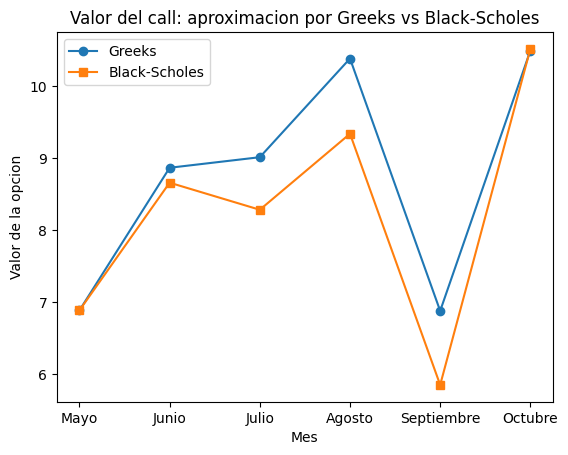

In [6]:
plt.plot(meses, V_g, marker="o", label="Greeks")
plt.plot(meses, V_bs, marker="s", label="Black-Scholes")
plt.title("Valor del call: aproximacion por Greeks vs Black-Scholes")
plt.xlabel("Mes")
plt.ylabel("Valor de la opcion")
plt.legend()
plt.show()

## 2.7 Extra: trayectoria mucho más volátil

create_paths simula el precio como movimiento browniano geométrico y create_vol la volatilidad como caminata con piso en 5 puntos. Se comparan 1000 trayectorias tranquilas contra 1000 muy volátiles, con semilla fija.

In [7]:
def create_paths(S_0, r, sigma, T, M):
    dt = T / M
    paths = np.zeros((M + 1,))
    paths[0] = S_0
    for t in range(1, M + 1):
        z = np.random.standard_normal()
        paths[t] = paths[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)
    return paths

def create_vol(sig_0, paso, M):
    vols = np.zeros((M + 1,))
    vols[0] = sig_0
    for t in range(1, M + 1):
        vols[t] = max(vols[t - 1] + paso * np.random.standard_normal(), 5)
    return vols

def error_max(S, sig):
    return np.max(np.abs(aprox_greeks(S, sig) - bs_serie(S, sig)))

np.random.seed(123)
n_sim = 1000
e_calma = np.zeros(n_sim)
e_volatil = np.zeros(n_sim)
for i in range(n_sim):
    S_c = create_paths(100, r, 0.15, 5 / 12, 5)
    sig_c = create_vol(20, 2, 5)
    S_v = create_paths(100, r, 0.60, 5 / 12, 5)
    sig_v = create_vol(20, 6, 5)
    e_calma[i] = error_max(S_c, sig_c)
    e_volatil[i] = error_max(S_v, sig_v)
print(np.mean(e_calma), np.median(e_calma))
print(np.mean(e_volatil), np.median(e_volatil))

np.random.seed(7)
S_v = create_paths(100, r, 0.60, 5 / 12, 5)
sig_v = create_vol(20, 6, 5)
tabla_v = pd.DataFrame({"Mes": meses, "Precio": S_v, "Vol": sig_v, "Greeks": aprox_greeks(S_v, sig_v), "BS": bs_serie(S_v, sig_v)})
tabla_v["Error"] = np.abs(tabla_v["Greeks"] - tabla_v["BS"])
print(tabla_v.round(2).to_string(index=False))

2.1428565960489743 1.8055058160851023
17.38165385001227 12.147134393341542
       Mes  Precio   Vol  Greeks    BS  Error
      Mayo  100.00 20.00    6.89  6.89   0.00
     Junio  132.57 20.01   40.20 34.68   5.52
     Julio  120.98 20.01   34.43 22.81  11.62
    Agosto  120.36  9.48   30.43 21.60   8.83
Septiembre  127.77 15.58   36.65 28.60   8.05
   Octubre  110.25 19.19   30.71 10.74  19.98


# 3. Respuestas

## Parte 1

| | A | B | C |
|---|---|---|---|
| Elasticidad (Delta·S/prima) | 0.85·100/12 = 7.08 | 0.50·100/8 = 6.25 | 0.20·100/5 = 4.00 |
| Vega/prima | 0.05/12 = 0.0042 | 0.25/8 = 0.0313 | 0.40/5 = 0.0800 |
| Theta/prima | 0.10/12 = 0.0083 | 0.03/8 = 0.0038 | 0.01/5 = 0.0020 |
| Valor intrínseco / temporal | 10 / 2 | 0 / 8 | 0 / 5 |
| Equilibrio al vencimiento | 102 (+2%) | 108 (+8%) | 125 (+25%) |


**P1. ¿Cuál es más sensible a cambios en el precio de la acción?**
Diría que A, sin mucha duda. Su delta es 0.85, la mayor de las tres, y también tiene la elasticidad más alta, 7.08. Por lo tanto, cualquier movimiento de la acción se refleja con más fuerza en esta opción.

**P2. ¿Cuál es más sensible a la volatilidad?**
La respuesta es C. Su vega llega a 0.40, así que un punto adicional de volatilidad equivale a cerca de 8% de su prima. Es la que tiene más que ganar si el mercado empieza a moverse con mayor incertidumbre.

**P3. ¿Cuál se deteriora más rápido con el tiempo?**
A es la que pierde valor con mayor rapidez. Su theta representa alrededor de 0.83% de la prima, por encima del 0.38% de B y del 0.20% de C. Como si fuera poco, solo le queda un mes antes del vencimiento.

**P4. ¿Cuál se parece más a la acción?**
Nuevamente A. Su delta de 0.85 hace que siga bastante de cerca los movimientos de la acción. Además, casi no depende de la volatilidad y 10 de sus 12 unidades de prima ya son valor intrínseco.

**P5. ¿Cuál depende más de un evento importante?**
C es la más ligada a que ocurra algo importante. Parte sin valor intrínseco y necesita que la acción pase de 125, un avance de 25%, para empezar a pagar. La ventaja es que su vega alto y su theta bajo le dan algo de margen para esperar ese movimiento.






## Parte 2

**A. Subida gradual, volatilidad constante. ¿Qué compro y qué evito?**
Me quedo con B y dejaría fuera C. Como la volatilidad permanece igual, el vega prácticamente no entra en juego. B ofrece una delta de 0.50 para acompañar el movimiento durante el periodo y, al mismo tiempo, tiene un theta relativamente pequeño (-0.03). A puede rendir más por cada dólar, pero vence en solo un mes; C, con delta de 0.20, apenas capturaría la subida.

**B. Anuncio en dos semanas, cambio brusco, dirección desconocida.**
Aquí no existe una respuesta completamente limpia: las tres deltas son positivas, de modo que comprar cualquiera de esos calls sigue siendo una apuesta alcista. Para un movimiento fuerte sin conocer la dirección, lo ideal sería un straddle. Entre las opciones disponibles, la alternativa más cercana es comprar B y neutralizar su delta vendiendo 0.50 acciones por opción; así se conserva exposición positiva a vega y gamma. Evitaría A, porque su vega de 0.05 la hace comportarse casi como la acción. El riesgo que permanece es el IV crush: si la volatilidad implícita baja 5 puntos, B perdería 15.6% de su prima y C alrededor de 40%.

**C. Acción muy estable.**
Tampoco hay una solución perfecta, ya que en este caso lo más lógico sería vender opciones y el menú solo permite comprarlas. Si de todos modos tengo que elegir, A es la opción menos desfavorable: como máximo perdería su valor temporal, que es 2, y su vega es muy bajo. Evitaría C. Con 30 días por delante y una disminución de 3 puntos en la volatilidad, C perdería cerca de 30% de su prima, mientras que B perdería 21% y A 17% (suponiendo un theta diario y lineal).

**D. Caída significativa.**
Ninguna de las tres encaja bien: todas pierden valor cuando la acción baja, y la posición más natural sería un put o una venta en corto. Si la elección es obligatoria, C resulta ser la menos expuesta. Para una caída de 10, la aproximación lineal estima pérdidas de 8.5 en A, 5.0 en B y 2.0 en C; además, en todos los casos la pérdida máxima está limitada a la prima pagada. Por eso descartaría A. Sin gamma, la pérdida observada probablemente sería algo menor que la estimación lineal.

**E. El mercado subestima la incertidumbre.**
Elegiría C y evitaría A. C es la que tiene más vega, 0.40: un aumento de 5 puntos en la volatilidad implícita añadiría 2.0 al valor, equivalente a 40% de su prima. Su theta de -0.01 también hace que esperar resulte relativamente barato. Aun así, queda un riesgo: mantiene una delta de 0.20, que podría cubrirse vendiendo 0.20 acciones, y si la volatilidad finalmente no aumenta, el paso del tiempo seguirá restando valor.


---


## Parte 3: verificaciones

**¿Qué T reproduce V0 = 6.8887 y Delta = 0.5977?**
El plazo que funciona es T = 0.5, o sea, seis meses. Al sustituirlo, d1 = [0 + (0.05 + 0.5·0.2²)·0.5] / (0.2·√0.5) = 0.2475 y d2 = 0.2475 − 0.1414 = 0.1061. De ahí salen N(d1) = 0.5977 y N(d2) = 0.5422. Finalmente, V = 100·0.5977 − 100·e^(−0.025)·0.5422 = 59.77 − 52.88 = 6.8887.

**¿Coinciden gamma, vega y theta?**
Gamma, con 0.02736, y theta, con −8.116, sí coinciden. La pequeña diferencia aparece en la vega: el cálculo da 0.2736 en vez de 0.2814, una variación de 2.9% que también se confirma con la derivada numérica. Para mantener el planteamiento de la tarea se utiliza 0.2814; aun así, el impacto máximo es de 0.08, menor que los errores observados, que van de 0.2 a 1.0.

**¿Por qué dsigma va en puntos porcentuales y no en decimal?**
Cuando sigma se expresa como decimal, la derivada de V vale 27.36. Al expresar la vega por punto porcentual se divide aproximadamente entre 100, de donde sale 0.2814. Si se tomara dsigma = 0.05 como si fuera la unidad correcta, el efecto de vega en junio sería apenas 0.014 en vez de 1.407. El error alcanzaría 2.06 en julio; octubre daría la impresión de estar bien, con 0.024, porque la volatilidad regresa a 20% y ese componente se anula. Para completar el cálculo, theta anualizado se convierte a mensual como −8.116·(1/12) = −0.676.

**¿Cómo funciona la recursión?**
La idea es conservar los greeks de mayo durante toda la trayectoria. Así, al sumar Delta·dS y Vega·dsigma paso a paso, los términos se simplifican hasta dar Delta·(S_t − S_0) y Vega·(sigma_t − sigma_0). El término que sí depende de cada movimiento intermedio es el de gamma. Para junio, por ejemplo, el cálculo queda 6.8887 + 1.1954 + 0.0547 + 1.4070 − 0.6763 = 8.8695, mientras que Black-Scholes produce 8.662.


---


## Parte 3: tablas

**(a) Aproximación por Greeks**

| Mes | Precio | Vol (%) | dS | dsigma | Valor (Greeks) |
|---|---|---|---|---|---|
| Mayo | 100 | 20 | - | - | 6.8887 |
| Junio | 102 | 25 | 2 | 5 | 8.8695 |
| Julio | 101 | 30 | -1 | 5 | 9.0161 |
| Agosto | 105 | 28 | 4 | -2 | 10.3867 |
| Septiembre | 103 | 22 | -2 | -6 | 6.8813 |
| Octubre | 110 | 20 | 7 | -2 | 10.4964 |

**(b) Greeks contra Black-Scholes**

| Mes | Greeks | Black-Scholes | Error absoluto |
|---|---|---|---|
| Mayo | - | 6.8887 | - |
| Junio | 8.8695 | 8.6621 | 0.2074 |
| Julio | 9.0161 | 8.2860 | 0.7301 |
| Agosto | 10.3867 | 9.3418 | 1.0449 |
| Septiembre | 6.8813 | 5.8530 | 1.0283 |
| Octubre | 10.4964 | 10.5202 | 0.0239 |

**Contribución de cada término**

| Mes | Delta·dS | ½·Gamma·dS² | Vega·dsigma | Theta·dt |
|---|---|---|---|---|
| Junio | 1.1954 | 0.0547 | 1.4070 | -0.6763 |
| Julio | -0.5977 | 0.0137 | 1.4070 | -0.6763 |
| Agosto | 2.3908 | 0.2189 | -0.5628 | -0.6763 |
| Septiembre | -1.1954 | 0.0547 | -1.6884 | -0.6763 |
| Octubre | 4.1839 | 0.6703 | -0.5628 | -0.6763 |
| Suma | 5.9770 | 1.0123 | 0.0000 | -3.3817 |

**Error por factor (Greeks − BS, con signo)**

| Mes | Solo S | Solo vol | Solo tiempo | Cruces | Error total |
|---|---|---|---|---|---|
| Junio | 0.001 | 0.036 | 0.022 | 0.149 | 0.207 |
| Julio | 0.055 | 0.068 | 0.096 | 0.511 | 0.730 |
| Agosto | -0.037 | 0.055 | 0.245 | 0.782 | 1.045 |
| Septiembre | 0.223 | 0.015 | 0.509 | 0.282 | 1.028 |
| Octubre | -0.197 | 0.000 | 0.995 | -0.822 | -0.024 |

## Parte 3: preguntas

**P1. ¿Los greeks iniciales describen con precisión toda la trayectoria?**
No completamente. En junio la diferencia todavía es de 0.21, pero sube a 1.04 en agosto, alrededor de 11% del valor de Black-Scholes, y a 1.03 en septiembre, cerca de 17.6%. Así que durante esos meses la aproximación queda por encima del valor real. El número casi perfecto de octubre no significa que el método haya funcionado mejor; ahí varios errores simplemente se compensaron.

**P2. ¿En qué mes apareció el error más grande?**
El mayor error absoluto se da en agosto, con 1.0449. Septiembre le sigue muy de cerca con 1.0283, aunque al medirlo como porcentaje del valor de Black-Scholes, septiembre termina siendo el peor caso.

**P3. ¿Qué factor contribuye más al error?**
El tiempo tiene el papel más importante. Por sí solo puede explicar hasta 0.995 de diferencia, ya que theta se vuelve más pronunciado conforme se acerca el vencimiento. A esto se suman los cruces entre variables, que pesan bastante de junio a agosto: 0.15, 0.51 y 0.78. La interacción más relevante es la de volatilidad con tiempo; el vega real cae de 0.2736 a 0.1146, mientras que la aproximación sigue trabajando con 0.2814. En cambio, el efecto aislado del precio llega como máximo a 0.22 y el de la volatilidad a 0.07. En octubre el error casi desaparece por casualidad: el +0.995 del tiempo se compensa con el cruce precio-tiempo de -0.82. Para entonces, con S = 110 y un mes restante, la delta real ya es 0.96 en lugar de 0.5977.

**P4. ¿Por qué los Greeks funcionan mejor con movimientos pequeños?**
Porque describen la función mediante una expansión de Taylor alrededor de un punto específico. Mientras el precio se mantiene cerca de ese punto, la aproximación suele ser razonable; cuando se aleja, empiezan a importar los términos que quedaron fuera y los greeks dejan de ser constantes. El primer término omitido crece con dS al cubo. También se puede ver con gamma: su peso relativo frente a delta es 0.0229·dS, así que pasa de 4.6% con dS = 2 a 16% con dS = 7.

**P5. Con una trayectoria mucho más volátil, ¿errores menores?**
No, los errores aumentan bastante. En las 1000 trayectorias de cada escenario, el error máximo medio pasa de 2.14 en el régimen tranquilo a 17.38 en el muy volátil, casi ocho veces más. En el ejemplo mostrado, octubre termina con un precio de 110.25, prácticamente igual que en la serie original, pero los greeks estiman 30.71 frente a 10.74 de Black-Scholes. Esto ocurre porque la recursión acumula ½·Gamma·dS² en cada paso, tanto cuando el precio sube como cuando baja. El valor de Black-Scholes, por su parte, depende del estado final y no de todos los movimientos intermedios.

**P6. Conclusión.**
La conclusión es que los greeks funcionan mejor como una herramienta local. Son útiles para movimientos pequeños y plazos cortos, pero pierden precisión si se mantienen fijos durante toda una trayectoria. Aquí el error alcanza 1.04 porque el tiempo modifica continuamente theta, vega y delta. Cuando la volatilidad aumenta, el error llega a multiplicarse entre seis y ocho veces, razón por la cual en la práctica los greeks se recalculan en cada rebalanceo. Además, como solo se consideran calls, ninguna de las tres opciones resuelve por sí sola los escenarios B y D.

---


# 4. Diccionario

- **Delta:** cambio del valor de la opción por cada dólar que cambia la acción.
- **Gamma:** cambio de la delta por cada dólar que se mueve la acción (curvatura).
- **Vega:** cambio del valor de la opción por cada punto de volatilidad.
- **Theta:** cambio del valor de la opción por el paso del tiempo; negativo para el comprador.
- **Volatilidad implícita:** la volatilidad que, metida en Black-Scholes, reproduce el precio de mercado.
- **Prima:** lo que cuesta la opción.
- **Valor intrínseco:** lo que pagaría la opción si se ejerciera hoy, max(S − K, 0) en un call.
- **Valor temporal:** prima menos valor intrínseco.
- **Moneyness (ITM/ATM/OTM):** ITM tiene valor intrínseco (call con S > K), ATM tiene S ≈ K, OTM no tiene valor intrínseco.
- **Expansión de Taylor:** aproximar una función cerca de un punto con sus derivadas.
- **Black-Scholes:** modelo de valuación de opciones europeas con precio lognormal, volatilidad constante y sin arbitraje.
- **Cobertura:** posición que compensa el riesgo de otra, por ejemplo vender acciones en corto para anular la delta de un call.
- **Straddle:** comprar un call y un put con el mismo strike y vencimiento; gana con movimientos grandes en cualquier dirección.
- **IV crush:** caída fuerte de la volatilidad implícita tras un evento esperado, que baja el precio de las opciones aunque la acción se mueva a favor.